# SkillsBench RQ1 Analysis

这个 notebook 只分析 `skillsbench` benchmark 下已经跑出来的 `MiniMax-M2.5` 结果。

当前范围：
- 只看 SkillsBench
- 只看 MiniMax
- 不包含 GPT 模型对比
- 同时覆盖性能分析和成本分析


In [1]:
import json
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans", "SimHei", "Arial Unicode MS"]
matplotlib.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("future.no_silent_downcasting", True)

PRIMARY_RESULTS_PATH = Path("/root/skill/results/rq1/skillsbench__minimax-cn-MiniMax-M2-5__recovered_full_87tasks.json")
TOKEN_PATCH_RESULTS_PATH = Path("/root/skill/results/rq1/skillsbench__minimax-cn-MiniMax-M2-5.json")
MERGED_RESULTS_PATH = Path("/root/skill/results/rq1/skillsbench__minimax-cn-MiniMax-M2-5__merged_with_token_patch.json")

TOKEN_PRICING_PATH = Path("/root/skill/analysis/rq1/token_pricing_cny_per_mtoken.json")
TOKEN_PRICING_CNY_PER_MTOKEN = json.loads(TOKEN_PRICING_PATH.read_text(encoding="utf-8"))
PRICE_CNY_PER_MTOKEN = TOKEN_PRICING_CNY_PER_MTOKEN["MiniMax-M2.5"]

JOB_ROOT = Path("/root/skillsbench/jobs")


In [2]:
for path in [PRIMARY_RESULTS_PATH, TOKEN_PATCH_RESULTS_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"SkillsBench result file not found: {path}")

print(f"Base results: {PRIMARY_RESULTS_PATH}")
print(f"Token patch results: {TOKEN_PATCH_RESULTS_PATH}")


Base results: /root/skill/results/rq1/skillsbench__minimax-cn-MiniMax-M2-5__recovered_full_87tasks.json
Token patch results: /root/skill/results/rq1/skillsbench__minimax-cn-MiniMax-M2-5.json


In [3]:
with PRIMARY_RESULTS_PATH.open("r", encoding="utf-8") as f:
    data = json.load(f)
with TOKEN_PATCH_RESULTS_PATH.open("r", encoding="utf-8") as f:
    token_patch_data = json.load(f)

tasks = data.get("tasks") or []
efficiency = data.get("efficiency") or {}
model = data.get("model", "unknown")
run_id = data.get("run_id", "")


def has_token_data(task):
    usage = task.get("usage") or {}
    if any(float(usage.get(key) or 0) > 0 for key in ["input_tokens", "output_tokens", "cache_read_tokens", "cache_write_tokens", "cache_tokens", "total_tokens"]):
        return True
    if any(float(v or 0) > 0 for v in (task.get("prompt_tokens_by_attempt") or [])):
        return True
    if any(float(v or 0) > 0 for v in (task.get("completion_tokens_by_attempt") or [])):
        return True
    for attempt in task.get("attempts") or []:
        attempt_usage = ((attempt.get("execution") or {}).get("usage") or attempt.get("usage") or {})
        if any(float(attempt_usage.get(key) or 0) > 0 for key in ["input_tokens", "output_tokens", "cache_read_tokens", "cache_write_tokens", "cache_tokens", "total_tokens"]):
            return True
    return False


def normalize_zero_token_task(task):
    normalized = dict(task)
    usage = dict(normalized.get("usage") or {})
    for key in ["input_tokens", "output_tokens", "cache_read_tokens", "cache_write_tokens", "cache_tokens", "total_tokens"]:
        usage[key] = float(usage.get(key) or 0)
    normalized["usage"] = usage
    if not normalized.get("prompt_tokens_by_attempt"):
        normalized["prompt_tokens_by_attempt"] = []
    if not normalized.get("completion_tokens_by_attempt"):
        normalized["completion_tokens_by_attempt"] = []
    normalized["token_imputed_as_zero"] = True
    return normalized


token_patch_by_task = {
    (task.get("task_id") or ""): task
    for task in (token_patch_data.get("tasks") or [])
    if task.get("task_id")
}

merged_tasks = []
patched_task_count = 0
for task in tasks:
    task_id = task.get("task_id") or ""
    patch_task = token_patch_by_task.get(task_id)
    if patch_task and has_token_data(patch_task):
        merged_tasks.append(patch_task)
        patched_task_count += 1
    else:
        merged_tasks.append(task)

tasks = [
    normalize_zero_token_task(task)
    if (not has_token_data(task) and int(task.get("attempt_count") or 0) == 0 and len(task.get("attempts") or []) == 0)
    else task
    for task in merged_tasks
]
tasks_missing_token_data = [
    task.get("task_id") or ""
    for task in tasks
    if not has_token_data(task) and not bool(task.get("token_imputed_as_zero", False))
]
if tasks_missing_token_data:
    raise ValueError(
        f"Merged task set still has missing token data for {len(tasks_missing_token_data)} tasks: {tasks_missing_token_data[:10]}"
    )


def detect_failure_reason(task):
    trial = task.get("source_trial")
    job = task.get("source_job")
    if not trial or not job:
        return "unknown", "missing source_trial/source_job"

    exception_path = JOB_ROOT / job / trial / "exception.txt"
    if not exception_path.exists():
        return "unknown", "missing exception.txt"

    text = exception_path.read_text(encoding="utf-8", errors="ignore")
    if "APITimeoutError" in text or "ConnectTimeout" in text or "Request timed out" in text:
        return "LLM API timeout", "APITimeoutError / ConnectTimeout / Request timed out"
    if "InternalServerError" in text or "Error code: 500" in text or "520 (1000)" in text:
        return "LLM API 500/520", "InternalServerError / 500 / 520 (1000)"
    if "context window exceeds limit (2013)" in text:
        return "Context limit", "BadRequestError: context window exceeds limit (2013)"
    if "TimeoutError" in text and "run_agent" in text:
        return "Agent timeout", "TimeoutError / asyncio.wait_for(agent.run(...))"
    return "Other", "See exception.txt"


def compute_cost(usage):
    usage = usage or {}
    return (
        float(usage.get("input_tokens") or 0) / 1_000_000 * PRICE_CNY_PER_MTOKEN["input_tokens"]
        + float(usage.get("output_tokens") or 0) / 1_000_000 * PRICE_CNY_PER_MTOKEN["output_tokens"]
        + float(usage.get("cache_read_tokens") or usage.get("cache_tokens") or 0) / 1_000_000 * PRICE_CNY_PER_MTOKEN["cache_read_tokens"]
        + float(usage.get("cache_write_tokens") or 0) / 1_000_000 * PRICE_CNY_PER_MTOKEN["cache_write_tokens"]
    )


def build_efficiency(tasks):
    per_task = []
    total_tokens = 0.0
    total_input_tokens = 0.0
    total_output_tokens = 0.0
    total_cache_tokens = 0.0
    total_cache_read_tokens = 0.0
    total_cache_write_tokens = 0.0
    total_cost_usd = 0.0
    total_requests = 0
    total_execution_time_seconds = 0.0

    for task in tasks:
        usage = task.get("usage") or {}
        task_total_tokens = float(usage.get("total_tokens") or 0)
        task_input_tokens = float(usage.get("input_tokens") or 0)
        task_output_tokens = float(usage.get("output_tokens") or 0)
        task_cache_read_tokens = float(usage.get("cache_read_tokens") or usage.get("cache_tokens") or 0)
        task_cache_write_tokens = float(usage.get("cache_write_tokens") or 0)
        task_cost_usd = float(usage.get("cost_usd") or 0)
        task_requests = int(usage.get("request_count") or 0)
        score = float(((task.get("grading") or {}).get("score")) or 0)
        passed = bool(task.get("status") == "success")

        total_tokens += task_total_tokens
        total_input_tokens += task_input_tokens
        total_output_tokens += task_output_tokens
        total_cache_tokens += task_cache_read_tokens
        total_cache_read_tokens += task_cache_read_tokens
        total_cache_write_tokens += task_cache_write_tokens
        total_cost_usd += task_cost_usd
        total_requests += task_requests
        total_execution_time_seconds += float(task.get("execution_time") or 0)

        per_task.append({
            "task_id": task.get("task_id", ""),
            "score": score,
            "passed": passed,
            "total_tokens": task_total_tokens,
            "cost_usd": task_cost_usd,
            "tokens_per_score_point": (task_total_tokens / score) if score > 0 else None,
            "tokens_per_success": task_total_tokens if passed else None,
        })

    task_count = len(tasks)
    success_count = sum(1 for task in tasks if task.get("status") == "success")
    total_score = sum(float(((task.get("grading") or {}).get("score")) or 0) for task in tasks)
    success_at_k = {}
    max_attempts = max((int(task.get("attempt_count") or 0) for task in tasks), default=0)
    for k in range(1, max_attempts + 1):
        success_at_k[str(k)] = round(
            sum(1 for task in tasks if (task.get("first_success_attempt") is not None and int(task.get("first_success_attempt") or 0) <= k)) / max(task_count, 1),
            6,
        )

    return {
        "total_tokens": total_tokens,
        "total_input_tokens": total_input_tokens,
        "total_output_tokens": total_output_tokens,
        "total_cache_tokens": total_cache_tokens,
        "total_cache_read_tokens": total_cache_read_tokens,
        "total_cache_write_tokens": total_cache_write_tokens,
        "total_cost_usd": total_cost_usd,
        "total_requests": total_requests,
        "total_execution_time_seconds": total_execution_time_seconds,
        "tasks_with_usage_data": sum(1 for task in tasks if has_token_data(task)),
        "tokens_per_task": (total_tokens / task_count) if task_count else None,
        "cost_per_task_usd": (total_cost_usd / task_count) if task_count else None,
        "score_per_1k_tokens": (total_score / (total_tokens / 1000.0)) if total_tokens else None,
        "score_per_dollar": (total_score / total_cost_usd) if total_cost_usd else None,
        "success_rate": (success_count / task_count) if task_count else None,
        "success_per_1k_tokens": (success_count / (total_tokens / 1000.0)) if total_tokens else None,
        "success_per_dollar": (success_count / total_cost_usd) if total_cost_usd else None,
        "success_at_k": success_at_k,
        "per_task": per_task,
    }


efficiency = build_efficiency(tasks)
merged_data = dict(data)
merged_data["tasks"] = tasks
merged_data["efficiency"] = efficiency
merged_data["token_patch_source"] = str(TOKEN_PATCH_RESULTS_PATH)
merged_data["merged_results_path"] = str(MERGED_RESULTS_PATH)
merged_data["patched_task_count"] = patched_task_count
with MERGED_RESULTS_PATH.open("w", encoding="utf-8") as f:
    json.dump(merged_data, f, ensure_ascii=False, indent=2)

task_rows = []
attempt_rows = []

for task in tasks:
    attempts = task.get("attempts") or []
    top_usage = task.get("usage") or {}
    task_cost_cny = compute_cost(top_usage)
    success = task.get("status") == "success"
    first_success_attempt = task.get("first_success_attempt")
    failure_reason, failure_evidence = detect_failure_reason(task) if not success else ("", "")

    task_rows.append({
        "task_id": task.get("task_id", ""),
        "status": task.get("status", ""),
        "success": success,
        "timed_out": bool(task.get("timed_out", False)),
        "attempt_count": int(task.get("attempt_count") or len(attempts) or 0),
        "attempt_records": len(attempts),
        "first_success_attempt": int(first_success_attempt) if first_success_attempt else pd.NA,
        "llm_rounds": int(task.get("llm_rounds") or 0),
        "execution_time_sec": float(task.get("execution_time") or 0),
        "reward": float(((task.get("grading") or {}).get("breakdown") or {}).get("reward") or 0),
        "input_tokens": float(top_usage.get("input_tokens") or 0),
        "output_tokens": float(top_usage.get("output_tokens") or 0),
        "cache_read_tokens": float(top_usage.get("cache_read_tokens") or top_usage.get("cache_tokens") or 0),
        "cache_write_tokens": float(top_usage.get("cache_write_tokens") or 0),
        "total_tokens": float(top_usage.get("total_tokens") or 0),
        "cost_cny": task_cost_cny,
        "cost_per_success_cny": task_cost_cny if success else pd.NA,
        "no_effective_attempt": (int(task.get("attempt_count") or 0) == 0 and len(attempts) == 0),
        "failure_reason": failure_reason,
        "failure_evidence": failure_evidence,
        "source_job": task.get("source_job", ""),
        "source_trial": task.get("source_trial", ""),
    })

    for attempt in attempts:
        execution = attempt.get("execution") or {}
        verifier = attempt.get("verifier") or {}
        usage = execution.get("usage") or attempt.get("usage") or {}
        reward = verifier.get("reward")
        attempt_rows.append({
            "task_id": task.get("task_id", ""),
            "attempt": int(attempt.get("attempt") or 0),
            "llm_rounds": int(execution.get("llm_rounds") or 0),
            "execution_time_sec": float(execution.get("execution_time") or 0),
            "input_tokens": float(usage.get("input_tokens") or 0),
            "output_tokens": float(usage.get("output_tokens") or 0),
            "cache_read_tokens": float(usage.get("cache_read_tokens") or usage.get("cache_tokens") or 0),
            "cache_write_tokens": float(usage.get("cache_write_tokens") or 0),
            "total_tokens": float(usage.get("total_tokens") or 0),
            "reward": float(reward) if reward is not None else pd.NA,
            "passed": reward == 1.0,
            "cost_cny": compute_cost(usage),
        })


df_tasks = pd.DataFrame(task_rows).sort_values(["success", "cost_cny", "task_id"], ascending=[False, False, True]).reset_index(drop=True)
df_attempts = pd.DataFrame(attempt_rows).sort_values(["attempt", "task_id"]).reset_index(drop=True)

print(f"Model: {model}")
print(f"Run ID: {run_id}")
print(f"Tasks: {len(df_tasks)}")
print(f"Attempt records: {len(df_attempts)}")
print(f"Tasks patched from token-complete file: {patched_task_count}")
print(f"Tasks with zero tokens imputed due to no effective attempt: {sum(bool(task.get('token_imputed_as_zero', False)) for task in tasks)}")
print("All merged tasks have token data.")
print(f"Merged full results saved to: {MERGED_RESULTS_PATH}")


Model: minimax-cn/MiniMax-M2.5
Run ID: a50af6c9
Tasks: 87
Attempt records: 159
Tasks patched from token-complete file: 54
Tasks with zero tokens imputed due to no effective attempt: 0
All merged tasks have token data.
Merged full results saved to: /root/skill/results/rq1/skillsbench__minimax-cn-MiniMax-M2-5__merged_with_token_patch.json


In [4]:
success_cost_cny = float(df_tasks[df_tasks["success"]]["cost_cny"].sum())
failed_cost_cny = float(df_tasks[~df_tasks["success"]]["cost_cny"].sum())
timeout_cost_cny = float(df_tasks[df_tasks["timed_out"]]["cost_cny"].sum())
error_non_timeout_cost_cny = float(df_tasks[(~df_tasks["success"]) & (~df_tasks["timed_out"])]["cost_cny"].sum())

summary = {
    "task_count": int(len(df_tasks)),
    "success_count": int(df_tasks["success"].sum()),
    "failure_count": int((~df_tasks["success"]).sum()),
    "success_rate": float(df_tasks["success"].mean()),
    "no_effective_attempt_failures": int(df_tasks["no_effective_attempt"].sum()),
    "mean_attempt_count": float(df_tasks["attempt_count"].mean()),
    "median_attempt_count": float(df_tasks["attempt_count"].median()),
    "mean_execution_time_sec": float(df_tasks["execution_time_sec"].mean()),
    "median_execution_time_sec": float(df_tasks["execution_time_sec"].median()),
    "total_cost_cny": float(df_tasks["cost_cny"].sum()),
    "success_cost_cny": success_cost_cny,
    "failed_cost_cny": failed_cost_cny,
    "timeout_cost_cny": timeout_cost_cny,
    "error_non_timeout_cost_cny": error_non_timeout_cost_cny,
    "mean_cost_per_task_cny": float(df_tasks["cost_cny"].mean()),
    "median_cost_per_task_cny": float(df_tasks["cost_cny"].median()),
}

for key, value in summary.items():
    print(f"{key}: {value}")

print("\nTop-level efficiency fields:")
for key, value in efficiency.items():
    if key != "per_task":
        print(f"  {key}: {value}")

print("\nSuccess by first_success_attempt:")
first_success = (
    df_tasks[df_tasks["success"]]
    .groupby("first_success_attempt")
    .size()
    .rename("tasks")
    .reset_index()
)
display(first_success)


task_count: 87
success_count: 45
failure_count: 42
success_rate: 0.5172413793103449
no_effective_attempt_failures: 0
mean_attempt_count: 1.8275862068965518
median_attempt_count: 2.0
mean_execution_time_sec: 1117.3793103448277
median_execution_time_sec: 930.0
total_cost_cny: 206.197348608
success_cost_cny: 82.356477696
failed_cost_cny: 123.84087091199999
timeout_cost_cny: 106.538418144
error_non_timeout_cost_cny: 17.302452768
mean_cost_per_task_cny: 2.3700844667586205
median_cost_per_task_cny: 1.311674112

Top-level efficiency fields:
  total_tokens: 221546201.0
  total_input_tokens: 113378076.0
  total_output_tokens: 2152869.0
  total_cache_tokens: 106015256.0
  total_cache_read_tokens: 106015256.0
  total_cache_write_tokens: 0.0
  total_cost_usd: 0.0
  total_requests: 4239
  total_execution_time_seconds: 97212.0
  tasks_with_usage_data: 87
  tokens_per_task: 2546508.057471264
  cost_per_task_usd: 0.0
  score_per_1k_tokens: 0.00020311790406191618
  score_per_dollar: None
  success_rate

,first_success_attempt,tasks
0,1,11
1,2,30
2,3,3
3,5,1


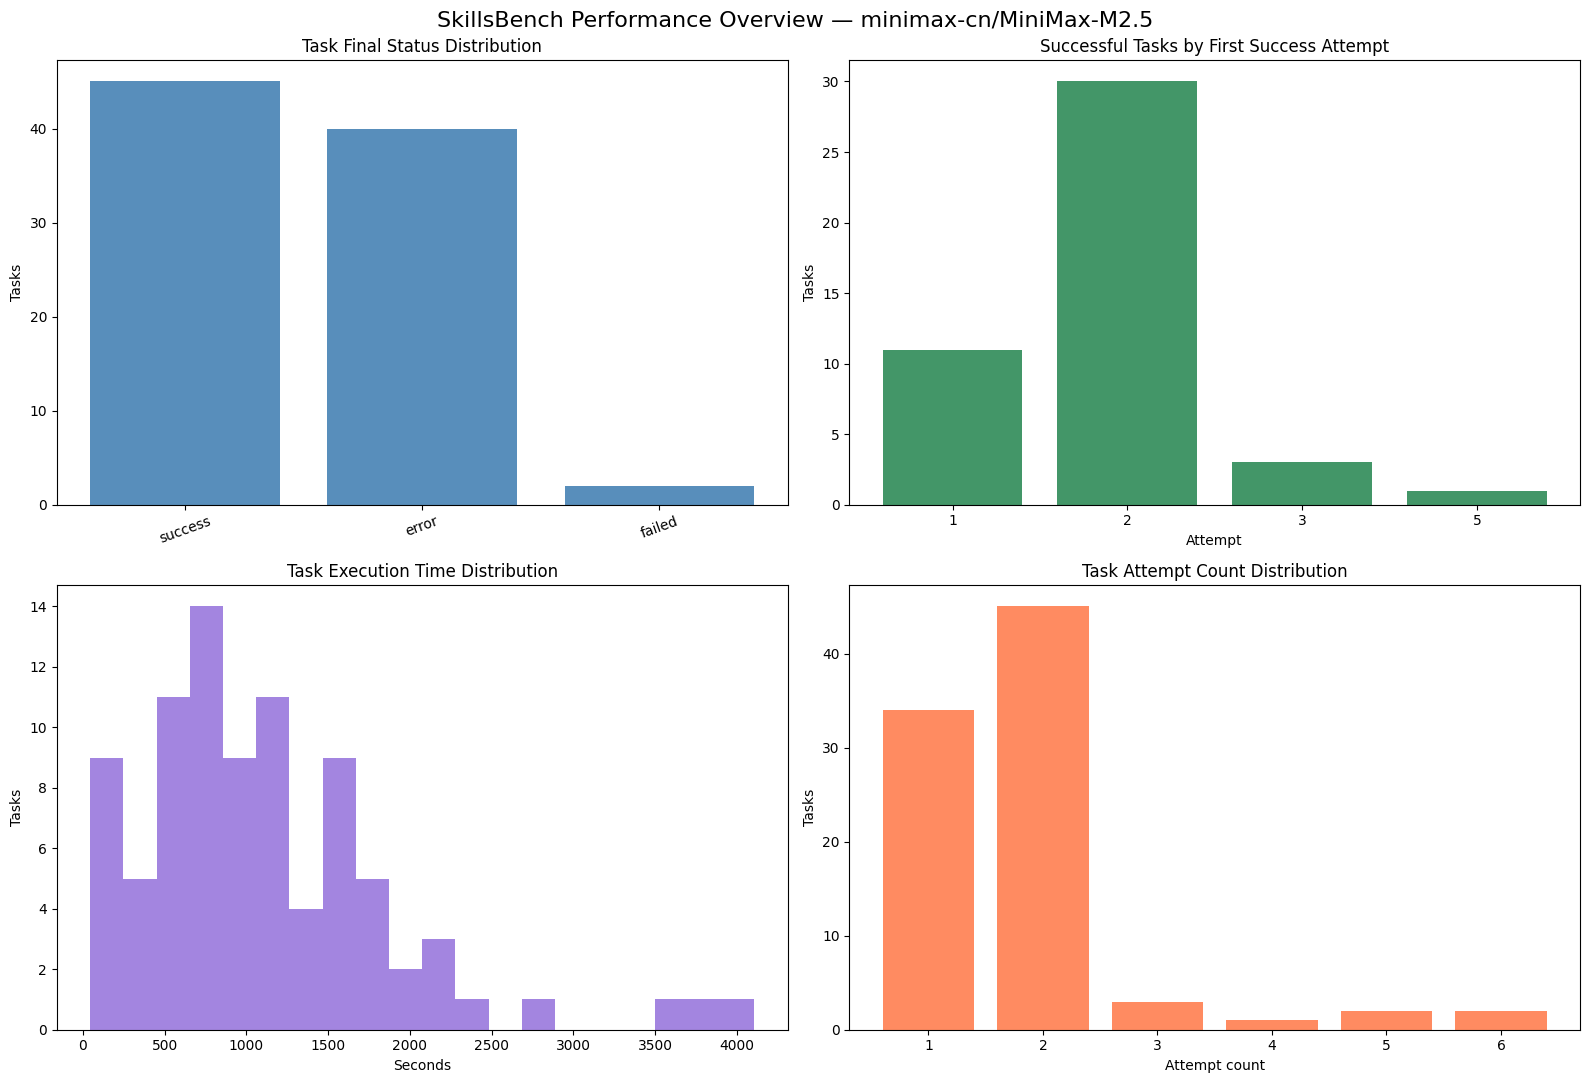

,task_id,status,attempt_count,first_success_attempt,llm_rounds,execution_time_sec,reward,no_effective_attempt,failure_reason
9,azure-bgp-oscillation-route-leak,success,5,5,106,1489.0,1.0,False,
2,enterprise-information-search,success,3,3,124,1288.0,1.0,False,
15,data-to-d3,success,3,3,42,846.0,1.0,False,
18,gh-repo-analytics,success,3,3,78,815.0,1.0,False,
1,weighted-gdp-calc,success,2,2,106,1762.0,1.0,False,
11,pg-essay-to-audiobook,success,2,2,57,1529.0,1.0,False,
3,civ6-adjacency-optimizer,success,2,2,139,1501.0,1.0,False,
28,exoplanet-detection-period,success,2,2,31,1352.0,1.0,False,
19,dynamic-object-aware-egomotion,success,2,2,42,1244.0,1.0,False,
23,sec-financial-report,success,2,2,38,1210.0,1.0,False,


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

status_counts = df_tasks["status"].value_counts().sort_values(ascending=False)
axes[0, 0].bar(status_counts.index, status_counts.values, color="steelblue", alpha=0.9)
axes[0, 0].set_title("Task Final Status Distribution")
axes[0, 0].set_ylabel("Tasks")
axes[0, 0].tick_params(axis="x", rotation=20)

success_by_attempt = (
    df_tasks[df_tasks["success"]]["first_success_attempt"]
    .fillna(0)
    .astype(int)
    .value_counts()
    .sort_index()
)
axes[0, 1].bar(success_by_attempt.index.astype(str), success_by_attempt.values, color="seagreen", alpha=0.9)
axes[0, 1].set_title("Successful Tasks by First Success Attempt")
axes[0, 1].set_xlabel("Attempt")
axes[0, 1].set_ylabel("Tasks")

axes[1, 0].hist(df_tasks["execution_time_sec"], bins=20, color="mediumpurple", alpha=0.85)
axes[1, 0].set_title("Task Execution Time Distribution")
axes[1, 0].set_xlabel("Seconds")
axes[1, 0].set_ylabel("Tasks")

attempt_counts = df_tasks["attempt_count"].value_counts().sort_index()
axes[1, 1].bar(attempt_counts.index.astype(str), attempt_counts.values, color="coral", alpha=0.9)
axes[1, 1].set_title("Task Attempt Count Distribution")
axes[1, 1].set_xlabel("Attempt count")
axes[1, 1].set_ylabel("Tasks")

plt.suptitle(f"SkillsBench Performance Overview — {model}", fontsize=16)
plt.tight_layout()
plt.show()

performance_view = df_tasks.sort_values(["success", "attempt_count", "execution_time_sec"], ascending=[False, False, False])[[
    "task_id", "status", "attempt_count", "first_success_attempt", "llm_rounds",
    "execution_time_sec", "reward", "no_effective_attempt", "failure_reason"
]]

display(performance_view)


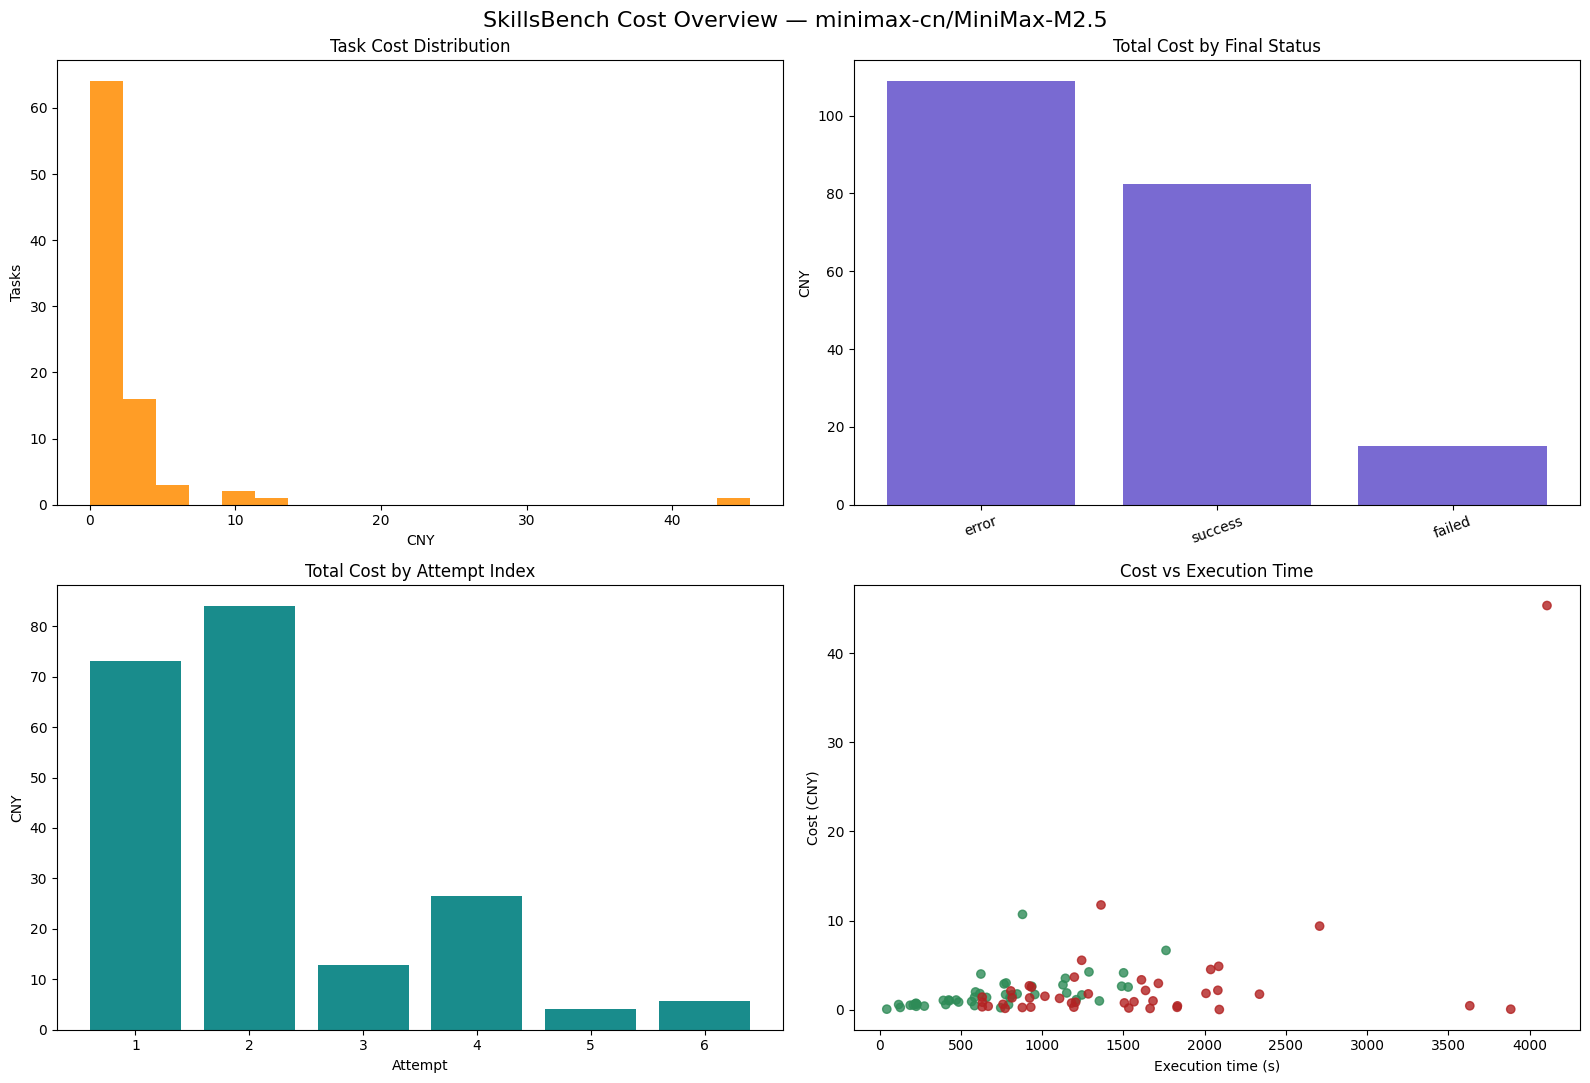

Top 15 most expensive tasks:


,task_id,status,attempt_count,execution_time_sec,input_tokens,output_tokens,cache_read_tokens,total_tokens,cost_cny
45,lab-unit-harmonization,error,4,4106.0,25338322.0,294528.0,24912640.0,50545490.0,45.358505
46,pddl-tpp-planning,failed,6,1362.0,6551174.0,85685.0,6323744.0,12960603.0,11.748474
0,manufacturing-fjsp-optimization,success,2,879.0,5864513.0,103812.0,5730048.0,11698373.0,10.693110
47,adaptive-cruise-control,error,2,2707.0,5176599.0,85569.0,4961088.0,10223256.0,9.375973
1,weighted-gdp-calc,success,2,1762.0,3660025.0,61093.0,3559776.0,7280894.0,6.647547
48,organize-messy-files,error,2,1243.0,3083358.0,41023.0,2994496.0,6118877.0,5.538743
49,earthquake-phase-association,error,2,2086.0,2672935.0,49836.0,2518144.0,5240915.0,4.861307
50,virtualhome-agent-planning,error,5,2037.0,2521551.0,33204.0,2379904.0,4934659.0,4.507701
2,enterprise-information-search,success,3,1288.0,2317555.0,49461.0,2121380.0,4488396.0,4.233132
3,civ6-adjacency-optimizer,success,2,1501.0,2255890.0,43587.0,2190912.0,4490389.0,4.130525


Success-task cost total: 82.3565 CNY
Failed-task cost total: 123.8409 CNY
Timed-out task cost total: 106.5384 CNY
Error but non-timeout task cost total: 17.3025 CNY
Cost share on failed tasks: 60.06%


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

axes[0, 0].hist(df_tasks["cost_cny"], bins=20, color="darkorange", alpha=0.85)
axes[0, 0].set_title("Task Cost Distribution")
axes[0, 0].set_xlabel("CNY")
axes[0, 0].set_ylabel("Tasks")

cost_by_status = df_tasks.groupby("status", as_index=False)["cost_cny"].sum().sort_values("cost_cny", ascending=False)
axes[0, 1].bar(cost_by_status["status"], cost_by_status["cost_cny"], color="slateblue", alpha=0.9)
axes[0, 1].set_title("Total Cost by Final Status")
axes[0, 1].set_ylabel("CNY")
axes[0, 1].tick_params(axis="x", rotation=20)

attempt_cost = df_attempts.groupby("attempt", as_index=False)["cost_cny"].sum()
axes[1, 0].bar(attempt_cost["attempt"].astype(str), attempt_cost["cost_cny"], color="teal", alpha=0.9)
axes[1, 0].set_title("Total Cost by Attempt Index")
axes[1, 0].set_xlabel("Attempt")
axes[1, 0].set_ylabel("CNY")

axes[1, 1].scatter(df_tasks["execution_time_sec"], df_tasks["cost_cny"], c=df_tasks["success"].map({True: "seagreen", False: "firebrick"}), alpha=0.8)
axes[1, 1].set_title("Cost vs Execution Time")
axes[1, 1].set_xlabel("Execution time (s)")
axes[1, 1].set_ylabel("Cost (CNY)")

plt.suptitle(f"SkillsBench Cost Overview — {model}", fontsize=16)
plt.tight_layout()
plt.show()

print("Top 15 most expensive tasks:")
display(df_tasks[[
    "task_id", "status", "attempt_count", "execution_time_sec", "input_tokens",
    "output_tokens", "cache_read_tokens", "total_tokens", "cost_cny"
]].sort_values("cost_cny", ascending=False).head(15))

print(f"Success-task cost total: {success_cost_cny:.4f} CNY")
print(f"Failed-task cost total: {failed_cost_cny:.4f} CNY")
print(f"Timed-out task cost total: {timeout_cost_cny:.4f} CNY")
print(f"Error but non-timeout task cost total: {error_non_timeout_cost_cny:.4f} CNY")
print(f"Cost share on failed tasks: {failed_cost_cny / max(success_cost_cny + failed_cost_cny, 1e-9):.2%}")


In [7]:
failed_tasks = df_tasks[~df_tasks["success"]].copy()
failed_reason_summary = failed_tasks.groupby("failure_reason", as_index=False).agg(
    tasks=("task_id", "count"),
    total_cost_cny=("cost_cny", "sum"),
    mean_execution_time_sec=("execution_time_sec", "mean"),
).sort_values(["tasks", "total_cost_cny"], ascending=[False, False])

print("Failure reason summary:")
display(failed_reason_summary)

print("Failure detail:")
display(failed_tasks[[
    "task_id", "status", "timed_out", "attempt_count", "execution_time_sec",
    "cost_cny", "failure_reason", "failure_evidence", "source_trial"
]].sort_values(["failure_reason", "cost_cny"], ascending=[True, False]))


Failure reason summary:


,failure_reason,tasks,total_cost_cny,mean_execution_time_sec
0,unknown,42,123.840871,1538.928571


Failure detail:


,task_id,status,timed_out,attempt_count,execution_time_sec,cost_cny,failure_reason,failure_evidence,source_trial
45,lab-unit-harmonization,error,True,4,4106.0,45.358505,unknown,missing exception.txt,lab-unit-harmonization__oZo3FJ7
46,pddl-tpp-planning,failed,False,6,1362.0,11.748474,unknown,missing exception.txt,pddl-tpp-planning__1hXwTan
47,adaptive-cruise-control,error,True,2,2707.0,9.375973,unknown,missing exception.txt,adaptive-cruise-control__TTavvZH
48,organize-messy-files,error,True,2,1243.0,5.538743,unknown,missing exception.txt,organize-messy-files__z4wixeS
49,earthquake-phase-association,error,True,2,2086.0,4.861307,unknown,missing exception.txt,earthquake-phase-association__N6tHknK
50,virtualhome-agent-planning,error,True,5,2037.0,4.507701,unknown,missing exception.txt,virtualhome-agent-planning__tatNx6y
51,scheduling-email-assistant,error,True,1,1198.0,3.649016,unknown,missing exception.txt,scheduling-email-assistant__ElhxNj5
52,xlsx-recover-data,failed,False,6,1611.0,3.344124,unknown,missing exception.txt,xlsx-recover-data__Rupg6i4
53,trend-anomaly-causal-inference,error,True,2,1715.0,2.945119,unknown,missing exception.txt,trend-anomaly-causal-inference__HhYrIkr
54,jpg-ocr-stat,error,True,2,921.0,2.670278,unknown,missing exception.txt,jpg-ocr-stat__lwpntln


In [ ]:
# 动态停止策略（SkillsBench-87 MiniMax）：当某次 attempt 的 score_delta == 0.0 时，在该次后停止累计后续 attempt
import pandas as pd

def _dynamic_cut_attempts_by_flat_delta(task):
    kept = []
    for attempt in task.get('attempts') or []:
        kept.append(attempt)
        delta = attempt.get('score_delta')
        if delta is not None and float(delta) == 0.0:
            break
    return kept

def _dynamic_first_success_attempt(task):
    first_success_attempt = task.get('first_success_attempt')
    if first_success_attempt is None:
        return None
    kept = _dynamic_cut_attempts_by_flat_delta(task)
    cutoff_attempt = max((int(a.get('attempt') or 0) for a in kept), default=0)
    return int(first_success_attempt) if int(first_success_attempt) <= cutoff_attempt else None

dynamic_full_rows = []
for task in tasks:
    kept_attempts = _dynamic_cut_attempts_by_flat_delta(task)
    dynamic_fsa = _dynamic_first_success_attempt(task)
    dynamic_cost = sum(_cost_cny_from_usage(((attempt.get('execution') or {}).get('usage') or attempt.get('usage') or {}), ACTIVE_MINIMAX_PRICE_CNY_PER_MTOKEN) for attempt in kept_attempts)
    dynamic_full_rows.append({
        'task_id': task.get('task_id', ''),
        'original_attempt_count': int(task.get('attempt_count') or len(task.get('attempts') or [])),
        'dynamic_attempt_count': len(kept_attempts),
        'success_standard': bool(task.get('success_within_budget')),
        'success_dynamic': dynamic_fsa is not None,
        'cost_cny_standard': sum(_cost_cny_from_usage(((attempt.get('execution') or {}).get('usage') or attempt.get('usage') or {}), ACTIVE_MINIMAX_PRICE_CNY_PER_MTOKEN) for attempt in (task.get('attempts') or [])),
        'cost_cny_dynamic': dynamic_cost,
        'truncated': len(kept_attempts) < int(task.get('attempt_count') or len(task.get('attempts') or [])),
    })

dynamic_full_df = pd.DataFrame(dynamic_full_rows)
dynamic_full_summary = {
    'task_count': int(len(dynamic_full_df)),
    'success_count_standard': int(dynamic_full_df['success_standard'].sum()),
    'success_count_dynamic': int(dynamic_full_df['success_dynamic'].sum()),
    'success_rate_standard': float(dynamic_full_df['success_standard'].mean()),
    'success_rate_dynamic': float(dynamic_full_df['success_dynamic'].mean()),
    'total_cost_cny_standard': float(dynamic_full_df['cost_cny_standard'].sum()),
    'total_cost_cny_dynamic': float(dynamic_full_df['cost_cny_dynamic'].sum()),
    'mean_cost_cny_standard': float(dynamic_full_df['cost_cny_standard'].mean()),
    'mean_cost_cny_dynamic': float(dynamic_full_df['cost_cny_dynamic'].mean()),
    'truncated_task_count': int(dynamic_full_df['truncated'].sum()),
}
for key, value in dynamic_full_summary.items():
    print(f'{key}: {value}')

print('Dynamic-stop truncation details:')
display(dynamic_full_df.sort_values(['truncated', 'cost_cny_standard', 'task_id'], ascending=[False, False, True]).reset_index(drop=True))


In [8]:
# 32-task cost-aware stratified subset for paper experiments
import tomllib

SUBSET_32_TASKS = [
    "threejs-structure-parser",
    "python-scala-translation",
    "fix-build-google-auto",
    "fix-build-agentops",
    "court-form-filling",
    "dialogue-parser",
    "powerlifting-coef-calc",
    "earthquake-phase-association",
    "dapt-intrusion-detection",
    "setup-fuzzing-py",
    "software-dependency-audit",
    "suricata-custom-exfil",
    "r2r-mpc-control",
    "energy-market-pricing",
    "financial-modeling-qa",
    "find-topk-similiar-chemicals",
    "react-performance-debugging",
    "glm-lake-mendota",
    "lake-warming-attribution",
    "latex-formula-extraction",
    "lean4-proof",
    "manufacturing-equipment-maintenance",
    "manufacturing-codebook-normalization",
    "mars-clouds-clustering",
    "offer-letter-generator",
    "parallel-tfidf-search",
    "pedestrian-traffic-counting",
    "quantum-numerical-simulation",
    "shock-analysis-demand",
    "reserves-at-risk-calc",
    "sec-financial-report",
    "spring-boot-jakarta-migration",
]

EXCLUDED_AS_COST_OUTLIERS = [
    "lab-unit-harmonization",
    "manufacturing-fjsp-optimization",
    "adaptive-cruise-control",
    "pddl-tpp-planning",
]

EXCLUDED_AS_ZERO_TOKEN_IMPUTED = [
    "video-tutorial-indexer",
    "virtualhome-agent-planning",
    "weighted-gdp-calc",
    "xlsx-recover-data",
]

task_meta_rows = []
for task_id in SUBSET_32_TASKS:
    task_toml = tomllib.loads((Path('/root/skillsbench/tasks') / task_id / 'task.toml').read_text(encoding='utf-8'))
    metadata = task_toml.get('metadata', {})
    task_meta_rows.append({
        'task_id': task_id,
        'category': metadata.get('category', 'unknown'),
        'difficulty': metadata.get('difficulty', 'unknown'),
        'tags': ', '.join(metadata.get('tags', [])),
    })

df_subset_meta = pd.DataFrame(task_meta_rows)
df_subset = df_tasks[df_tasks['task_id'].isin(SUBSET_32_TASKS)].copy()
df_subset = df_subset.merge(df_subset_meta, on='task_id', how='left')

if len(df_subset) != len(SUBSET_32_TASKS):
    missing = sorted(set(SUBSET_32_TASKS) - set(df_subset['task_id']))
    raise ValueError(f'Subset task count mismatch: expected {len(SUBSET_32_TASKS)}, got {len(df_subset)}; missing={missing}')

subset_summary = {
    'subset_task_count': int(len(df_subset)),
    'subset_success_count': int(df_subset['success'].sum()),
    'subset_failure_count': int((~df_subset['success']).sum()),
    'subset_success_rate': float(df_subset['success'].mean()),
    'subset_total_cost_cny': float(df_subset['cost_cny'].sum()),
    'subset_mean_cost_cny': float(df_subset['cost_cny'].mean()),
    'subset_median_cost_cny': float(df_subset['cost_cny'].median()),
    'subset_success_cost_cny': float(df_subset.loc[df_subset['success'], 'cost_cny'].sum()),
    'subset_failure_cost_cny': float(df_subset.loc[~df_subset['success'], 'cost_cny'].sum()),
}

print('32-task subset summary for MiniMax-M2.5:')
for key, value in subset_summary.items():
    print(f'  {key}: {value}')

print('\nCategory distribution:')
display(df_subset.groupby('category').size().rename('tasks').sort_values(ascending=False).reset_index())

print('Difficulty distribution:')
display(df_subset.groupby('difficulty').size().rename('tasks').sort_values(ascending=False).reset_index())

display(
    df_subset[[
        'task_id', 'category', 'difficulty', 'success', 'reward', 'cost_cny',
        'attempt_count', 'execution_time_sec', 'input_tokens', 'output_tokens', 'total_tokens'
    ]]
    .sort_values(['category', 'cost_cny', 'task_id'], ascending=[True, False, True])
    .reset_index(drop=True)
)


32-task subset summary for MiniMax-M2.5:
  subset_task_count: 32
  subset_success_count: 12
  subset_failure_count: 20
  subset_success_rate: 0.375
  subset_total_cost_cny: 39.0916224
  subset_mean_cost_cny: 1.2216132
  subset_median_cost_cny: 0.973056816
  subset_success_cost_cny: 16.080587712000003
  subset_failure_cost_cny: 23.011034688000002

Category distribution:


,category,tasks
0,security,3
1,Compilation & Build,2
2,manufacturing,2
3,financial-analysis,2
4,3d-graphics,1
5,environmental-modeling,1
6,seismology,1
7,quantum-simulation,1
8,pedestrian traffic counting,1
9,latex-extraction,1


Difficulty distribution:


,difficulty,tasks
0,medium,16
1,hard,10
2,easy,6


,task_id,category,difficulty,success,reward,cost_cny,attempt_count,execution_time_sec,input_tokens,output_tokens,total_tokens
0,threejs-structure-parser,3d-graphics,medium,True,1.0,0.908307,2,566.0,501617.0,9360.0,969537.0
1,python-scala-translation,Code Translation,medium,False,0.0,1.311674,1,923.0,676724.0,26569.0,1342717.0
2,fix-build-agentops,Compilation & Build,easy,False,0.0,2.100853,2,807.0,1132192.0,28173.0,2230573.0
3,fix-build-google-auto,Compilation & Build,easy,False,0.0,1.263959,2,1107.0,698539.0,12393.0,1359124.0
4,spring-boot-jakarta-migration,Legacy Systems,hard,False,0.0,1.325556,1,815.0,765142.0,11585.0,1321943.0
5,parallel-tfidf-search,Parallelization,medium,True,1.0,0.452978,1,584.0,217718.0,14587.0,424817.0
6,suricata-custom-exfil,Security & CTF,medium,True,1.0,1.353745,2,802.0,751400.0,11700.0,1472604.0
7,find-topk-similiar-chemicals,chemistry,medium,False,0.0,0.280679,1,930.0,148621.0,4977.0,285534.0
8,r2r-mpc-control,control-systems,medium,False,0.0,0.754567,1,1506.0,369388.0,22363.0,717575.0
9,powerlifting-coef-calc,data-analysis,easy,True,1.0,0.659663,1,221.0,365730.0,7544.0,684239.0
